# Feature Space v2: weighted 8D extractor for SocialFX + OPRA

Этот ноутбук переводит оба набора кривых в новое weighted 8D-пространство:

```text
[sub_bass, bass, lowmid, warmth, presence, clarity, air, brightness]
```

Входы:

```text
outputs/socialfx_curves_with_6d.parquet
outputs/opra_eq_profiles.parquet
```

Выходы:

```text
outputs/socialfx_curves_with_8d.parquet
outputs/opra_eq_profiles_with_8d.parquet
outputs/feature_space_v2_8d_stats.csv
outputs/socialfx_opra_8d_features.parquet
```

Идея: сначала не обучаем mapper, а проверяем, как SocialFX и OPRA распределяются в новом weighted 8D-пространстве.


In [1]:
# ==== Imports and paths ====

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


OUTPUT_DIR = Path("outputs")

SOCIALFX_FILE = OUTPUT_DIR / "socialfx_curves_with_6d.parquet"

# Primary OPRA files from opra_eq_dataset_extract.ipynb
OPRA_FILE_PARQUET = OUTPUT_DIR / "opra_eq_profiles.parquet"
OPRA_FILE_CSV = OUTPUT_DIR / "opra_eq_profiles.csv"

# Legacy fallback, in case the previous notebook version was already run
LEGACY_EXTERNAL_FILE_PARQUET = OUTPUT_DIR / "OPRA_eq_profiles.parquet"
LEGACY_EXTERNAL_FILE_CSV = OUTPUT_DIR / "OPRA_eq_profiles.csv"

SOCIALFX_OUT = OUTPUT_DIR / "socialfx_curves_with_8d.parquet"
OPRA_OUT = OUTPUT_DIR / "opra_eq_profiles_with_8d.parquet"

FEATURE_STATS_OUT = OUTPUT_DIR / "feature_space_v2_8d_stats.csv"
COMBINED_FEATURES_OUT = OUTPUT_DIR / "socialfx_opra_8d_features.parquet"


FEATURE_NAMES_8D = [
    "sub_bass",
    "bass",
    "lowmid",
    "warmth",
    "presence",
    "clarity",
    "air",
    "brightness",
]


print("SocialFX:", SOCIALFX_FILE.resolve())
print("OPRA:", OPRA_FILE_PARQUET.resolve())
print("Outputs:", OUTPUT_DIR.resolve())


SocialFX: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\socialfx_curves_with_6d.parquet
OPRA: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\opra_eq_profiles.parquet
Outputs: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs


## 1. Load SocialFX and OPRA EQ profiles

SocialFX уже содержит `curve_23` и `freqs_23`.

OPRA-файл был создан предыдущим ноутбуком `opra_eq_dataset_extract.ipynb`. Там `curve_23` хранится как JSON-строка.

Если у тебя уже был создан старый файл `OPRA_eq_profiles.parquet`, загрузчик ниже сможет использовать его как legacy fallback, но в новых выводах всё равно будет явно подписано как OPRA.


In [2]:
# ==== Load helpers ====

def parse_array_value(value):
    """
    Универсальный парсер для массивов, которые могут прийти как:
    - list / ndarray;
    - JSON string;
    - строка вида "[1, 2, 3]".
    """
    if isinstance(value, np.ndarray):
        return value.astype(np.float32)

    if isinstance(value, list):
        return np.asarray(value, dtype=np.float32)

    if isinstance(value, str):
        return np.asarray(json.loads(value), dtype=np.float32)

    raise TypeError(f"Unsupported array value type: {type(value)}")


def load_socialfx(path=SOCIALFX_FILE):
    if not path.exists():
        raise FileNotFoundError(f"SocialFX file not found: {path}")

    df = pd.read_parquet(path).copy()

    if "curve_23" not in df.columns:
        raise ValueError("SocialFX file must contain curve_23 column.")

    df["curve_23"] = df["curve_23"].apply(parse_array_value)

    if "freqs_23" in df.columns:
        df["freqs_23"] = df["freqs_23"].apply(parse_array_value)
        freqs = np.asarray(df.iloc[0]["freqs_23"], dtype=float)
    else:
        raise ValueError("SocialFX file must contain freqs_23 column.")

    df["source_dataset"] = "socialfx"

    return df, freqs


def load_opra_profiles(
    parquet_path=OPRA_FILE_PARQUET,
    csv_path=OPRA_FILE_CSV,
    legacy_parquet_path=LEGACY_EXTERNAL_FILE_PARQUET,
    legacy_csv_path=LEGACY_EXTERNAL_FILE_CSV,
):
    """
    Loads OPRA profiles.

    Primary paths:
      outputs/opra_eq_profiles.parquet
      outputs/opra_eq_profiles.csv

    Legacy fallback:
      outputs/OPRA_eq_profiles.parquet
      outputs/OPRA_eq_profiles.csv
    """
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path).copy()
        source_path = parquet_path
    elif csv_path.exists():
        df = pd.read_csv(csv_path).copy()
        source_path = csv_path
    elif legacy_parquet_path.exists():
        df = pd.read_parquet(legacy_parquet_path).copy()
        source_path = legacy_parquet_path
        print("Loaded OPRA from legacy file:", legacy_parquet_path)
    elif legacy_csv_path.exists():
        df = pd.read_csv(legacy_csv_path).copy()
        source_path = legacy_csv_path
        print("Loaded OPRA from legacy file:", legacy_csv_path)
    else:
        raise FileNotFoundError(
            "OPRA profile file not found. Expected one of: "
            f"{parquet_path}, {csv_path}, {legacy_parquet_path}, {legacy_csv_path}"
        )

    if "curve_23_json" in df.columns:
        df["curve_23"] = df["curve_23_json"].apply(
            lambda s: np.asarray(json.loads(s), dtype=np.float32)
        )
    elif "curve_23" in df.columns:
        df["curve_23"] = df["curve_23"].apply(parse_array_value)
    else:
        raise ValueError("OPRA file must contain curve_23_json or curve_23.")

    # Normalize dataset label.
    df["source_dataset"] = "opra"

    print("Loaded OPRA profiles from:", source_path)
    return df


df_socialfx, freqs_23 = load_socialfx()
df_opra = load_opra_profiles()

print("SocialFX rows:", len(df_socialfx))
print("OPRA rows:", len(df_opra))
print("freqs_23:", freqs_23)
print("num bands:", len(freqs_23))

display(df_socialfx.head())
display(df_opra.head())


Loaded OPRA profiles from: outputs\opra_eq_profiles.parquet
SocialFX rows: 1595
OPRA rows: 12593
freqs_23: [   20.            50.            83.           120.
   159.51029968   200.04376221   254.04821777   308.56271362
   383.           443.86398315   622.04351807   798.06713867
  1000.          1485.98254395  1875.          2368.08081055
  3389.64819336  4365.36328125  6934.26074219  8568.99511719
 12000.         14000.         16000.        ]
num bands: 23


,id,text,lang,ratings_consistency,curve_40,curve_23,freqs_40,freqs_23,n_bands_40,n_bands_23,...,air_23,lowmid_40_raw,lowmid_23_raw,lowmid_40,lowmid_23,sparkle_40_raw,sparkle_23_raw,sparkle_40,sparkle_23,source_dataset
0,eq_0,hot,English,0.797209,"[-1.2872984409332275, -1.5329641103744507, -1....","[-1.2872984, -1.5329641, -1.5065393, -1.396974...","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...",40,23,...,-0.684178,0.033145,-0.102991,-0.123303,-0.256713,-0.597603,-0.602004,-0.773750,-0.730522,socialfx
1,eq_1,wet,English,0.481343,"[-0.9765962958335876, -0.7818208336830139, -0....","[-0.9765963, -0.78182083, -0.56064045, -0.6097...","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...",40,23,...,2.180072,-0.890200,-0.913966,-1.056473,-1.032669,1.272812,1.481533,2.125769,2.346461,socialfx
2,eq_10,warm,English,0.806225,"[1.970152497291565, 2.0636439323425293, 2.1096...","[1.9701525, 2.063644, 2.1096215, 2.019063, 1.8...","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...",40,23,...,-0.825903,0.981721,1.114597,0.835368,0.908299,-0.561150,-0.648133,-0.717241,-0.798645,socialfx
3,eq_100,calm,English,0.754685,"[1.3558952808380127, 1.202727198600769, 1.1038...","[1.3558953, 1.2027272, 1.1038468, 0.9991057, 0...","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...",40,23,...,1.113007,0.001751,0.096301,-0.155030,-0.066026,0.490724,0.479767,0.913375,0.867046,socialfx
4,eq_1000,angelical,Español,0.428656,"[0.09275069832801819, 0.3474467396736145, 0.57...","[0.0927507, 0.34744674, 0.57004803, 0.8858108,...","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...",40,23,...,0.864598,1.073017,1.202731,0.927636,0.992628,0.545679,0.612955,0.998566,1.063739,socialfx


,source_dataset,relative_path,filename,suffix,profile_type,num_points,num_filters,gain_min,gain_max,gain_abs_max,...,gain_1875_0hz,gain_2368_080810546875hz,gain_3389_648193359375hz,gain_4365_36328125hz,gain_6934_2607421875hz,gain_8568_9951171875hz,gain_12000_0hz,gain_14000_0hz,gain_16000_0hz,curve_23
0,opra,database\vendors\1custom\products\sa02\eq\auto...,info.json,.json,json_parametric,0,10,-1.055203,5.488164,5.488164,...,-0.000903,-0.002575,-0.009955,-0.026191,-0.160196,-0.344945,-0.811882,-0.976374,-1.055203,"[5.4881635, 5.1938915, 3.9035857, 2.0669541, 0..."
1,opra,database\vendors\1custom\products\sa03\eq\auto...,info.json,.json,json_parametric,0,10,-1.822291,2.395032,2.395032,...,-0.002102,-0.004782,-0.017416,-0.045524,-0.277582,-0.596611,-1.401456,-1.685727,-1.822291,"[2.3950322, 2.271908, 1.7140299, 0.8947236, 0...."
2,opra,database\vendors\1custom\products\sa05\eq\auto...,info.json,.json,json_parametric,0,10,-2.397266,2.893972,2.893972,...,-0.002796,-0.006331,-0.023032,-0.060197,-0.366467,-0.786137,-1.842735,-2.216990,-2.397266,"[2.8939717, 2.7445095, 2.0696988, 1.0820913, 0..."
3,opra,database\vendors\1more\products\1m301_single_d...,info.json,.json,json_parametric,0,7,0.000483,9.989346,9.989346,...,0.001564,0.004633,0.021579,0.061138,0.336463,0.584065,0.901797,0.964261,0.988650,"[9.9893465, 9.523152, 7.374416, 4.215076, 2.02..."
4,opra,database\vendors\1more\products\aero\eq\autoeq...,info.json,.json,json_parametric,0,10,0.000390,3.641548,3.641548,...,0.004637,0.009952,0.035626,0.092945,0.562815,1.200172,2.794952,3.364777,3.641548,"[0.09979513, 0.09471751, 0.07152903, 0.0372154..."


## 2. 8D extractor

Новые признаки:

```text
sub_bass     20–80 Hz
bass         80–200 Hz
lowmid       200–500 Hz
warmth       500–1000 Hz
presence     1000–4000 Hz
clarity      4000–8000 Hz
air          8000–16000 Hz
brightness   mean(4–16 kHz) - mean(20–500 Hz)
```

`brightness` заменяет старый `tilt`, потому что он проще и стабильнее: это не глобальная наклонная ось, а понятный баланс верхов относительно низа/нижней середины.


In [3]:
# ==== Weighted 8D feature extractor ====

FEATURE_NAMES_8D = [
    "sub_bass",
    "bass",
    "lowmid",
    "warmth",
    "presence",
    "clarity",
    "air",
    "brightness",
]


def gaussian_weights(freqs_hz, center_hz, sigma_oct):
    freqs_hz = np.asarray(freqs_hz, dtype=np.float64)

    log_f = np.log2(freqs_hz)
    center = np.log2(float(center_hz))

    x = (log_f - center) / float(sigma_oct)
    w = np.exp(-0.5 * (x ** 2))

    s = w.sum()
    if s > 0:
        w = w / s

    return w.astype(np.float64)


def high_shelf_weights(freqs_hz, start_hz, slope_oct):
    freqs_hz = np.asarray(freqs_hz, dtype=np.float64)

    x = (np.log2(freqs_hz) - np.log2(float(start_hz))) / float(slope_oct)
    w = 1.0 / (1.0 + np.exp(-x))

    w = w - w.min()

    s = w.sum()
    if s > 0:
        w = w / s

    return w.astype(np.float64)


def low_shelf_weights(freqs_hz, end_hz, slope_oct):
    freqs_hz = np.asarray(freqs_hz, dtype=np.float64)

    x = (np.log2(freqs_hz) - np.log2(float(end_hz))) / float(slope_oct)
    w = 1.0 / (1.0 + np.exp(x))

    w = w - w.min()

    s = w.sum()
    if s > 0:
        w = w / s

    return w.astype(np.float64)


def build_weight_bank_8d(freqs_hz):
    """
    Weighted perceptual feature bank.

    Обычные признаки:
      value = sum(curve * normalized_weights)

    brightness:
      value = sum(curve * high_weights) - sum(curve * low_weights)
    """

    weights = {}

    weights["sub_bass"] = gaussian_weights(
        freqs_hz,
        center_hz=45,
        sigma_oct=0.75,
    )

    weights["bass"] = gaussian_weights(
        freqs_hz,
        center_hz=120,
        sigma_oct=0.70,
    )

    weights["lowmid"] = gaussian_weights(
        freqs_hz,
        center_hz=350,
        sigma_oct=0.75,
    )

    weights["warmth"] = gaussian_weights(
        freqs_hz,
        center_hz=700,
        sigma_oct=0.75,
    )

    weights["presence"] = gaussian_weights(
        freqs_hz,
        center_hz=2500,
        sigma_oct=0.80,
    )

    weights["clarity"] = gaussian_weights(
        freqs_hz,
        center_hz=5500,
        sigma_oct=0.75,
    )

    weights["air"] = high_shelf_weights(
        freqs_hz,
        start_hz=8000,
        slope_oct=0.75,
    )

    low_w = low_shelf_weights(
        freqs_hz,
        end_hz=500,
        slope_oct=0.85,
    )

    high_w = high_shelf_weights(
        freqs_hz,
        start_hz=4000,
        slope_oct=0.85,
    )

    weights["brightness"] = high_w - low_w

    return weights


def extract_8d_from_curve(curve, freqs_hz, weight_bank=None):
    curve = np.asarray(curve, dtype=np.float64)

    if weight_bank is None:
        weight_bank = build_weight_bank_8d(freqs_hz)

    z = []

    for name in FEATURE_NAMES_8D:
        w = weight_bank[name]
        value = float(np.sum(curve * w))
        z.append(value)

    return np.asarray(z, dtype=np.float32)


def add_8d_features(df, freqs, curve_col="curve_23", prefix="z8"):
    df = df.copy()

    weight_bank = build_weight_bank_8d(freqs)

    z_values = np.stack(
        [
            extract_8d_from_curve(
                curve,
                freqs_hz=freqs,
                weight_bank=weight_bank,
            )
            for curve in df[curve_col].values
        ]
    )

    df["z8_raw"] = list(z_values.astype(np.float32))

    for i, name in enumerate(FEATURE_NAMES_8D):
        df[f"{prefix}_{name}"] = z_values[:, i]

    return df


# Quick smoke test
test_weight_bank = build_weight_bank_8d(freqs_23)
test_z = extract_8d_from_curve(
    df_socialfx.iloc[0]["curve_23"],
    freqs_hz=freqs_23,
    weight_bank=test_weight_bank,
)

dict(zip(FEATURE_NAMES_8D, test_z))

{'sub_bass': np.float32(-1.4655186),
 'bass': np.float32(-1.177465),
 'lowmid': np.float32(0.27107856),
 'warmth': np.float32(1.1588559),
 'presence': np.float32(0.44201794),
 'clarity': np.float32(-0.24656537),
 'air': np.float32(-0.5567696),
 'brightness': np.float32(0.18123376)}

In [4]:
# ==== Frequency axis style ====

from matplotlib.ticker import NullFormatter

def format_freq_label(f):
        if f >= 1000:
            if f % 1000 == 0:
                return f"{int(f/1000)}k"
            if f >= 10000:
                return f"{int(f/1000)}k"
            return f"{f/1000:.1f}k"
        return str(int(round(f)))

def style_freq_axis(
    ax,
    freqs,
    xlabel="Frequency (Hz)",
    ylabel=None,
    title=None,
    ylim=None,
    legend=True,
    legend_ncol=2,
):
    freqs = np.asarray(freqs, dtype=float)

    ax.set_xscale("log")
    ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if title is not None:
        ax.set_title(title)

    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.12)

    nice_ticks = np.array(
        [20, 50, 83, 120, 200, 383, 622, 1000, 1500, 2400, 4400, 6900, 12000, 16000],
        dtype=float,
    )

    nice_ticks = nice_ticks[
        (nice_ticks >= freqs.min()) & (nice_ticks <= freqs.max())
    ]

    ax.set_xticks(nice_ticks)
    ax.set_xticklabels(
        [format_freq_label(f) for f in nice_ticks],
        rotation=0,
    )
    ax.xaxis.set_minor_formatter(NullFormatter())

    if ylim is not None:
        ax.set_ylim(*ylim)

    if legend:
        ax.legend(loc="best", ncol=legend_ncol)

    plt.tight_layout()

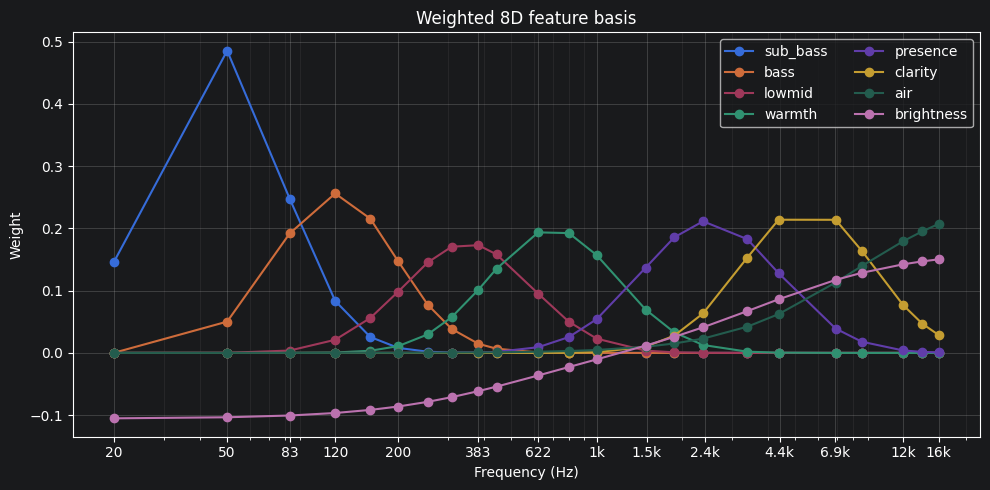

In [5]:
# ==== Visualize weighted 8D feature basis ====

weight_bank = build_weight_bank_8d(freqs_23)

fig, ax = plt.subplots(figsize=(10, 5))

for name in FEATURE_NAMES_8D:
    ax.plot(
        freqs_23,
        weight_bank[name],
        marker="o",
        label=name,
    )

style_freq_axis(
    ax,
    freqs_23,
    ylabel="Weight",
    title="Weighted 8D feature basis",
    legend=True,
    legend_ncol=2,
)

plt.show()

## 3. Extract raw 8D features

Сначала считаем raw 8D в dB-scale без нормализации.


In [6]:
# ==== Add raw 8D features ====

df_socialfx_8d = add_8d_features(
    df_socialfx,
    freqs=freqs_23,
    curve_col="curve_23",
    prefix="z8",
)

df_opra_8d = add_8d_features(
    df_opra,
    freqs=freqs_23,
    curve_col="curve_23",
    prefix="z8",
)

print("SocialFX 8D:", df_socialfx_8d.shape)
print("OPRA 8D:", df_opra_8d.shape)

display(df_socialfx_8d[[f"z8_{n}" for n in FEATURE_NAMES_8D]].head())
display(df_opra_8d[[f"z8_{n}" for n in FEATURE_NAMES_8D]].head())


SocialFX 8D: (1595, 44)
OPRA 8D: (12593, 46)


,z8_sub_bass,z8_bass,z8_lowmid,z8_warmth,z8_presence,z8_clarity,z8_air,z8_brightness
0,-1.465519,-1.177465,0.271079,1.158856,0.442018,-0.246565,-0.556770,0.181234
1,-0.743789,-0.763561,-0.867433,-0.746504,-0.290277,0.634404,1.406848,1.857543
2,2.045807,1.816059,0.795044,-0.245420,-0.313444,-0.378366,-0.626217,-1.857467
3,1.165846,0.800731,-0.171830,-1.019862,-0.470916,0.608279,0.416424,-0.089782
4,0.446425,1.051815,0.885177,-0.379762,-0.807434,-0.157518,0.565043,-0.363272


,z8_sub_bass,z8_bass,z8_lowmid,z8_warmth,z8_presence,z8_clarity,z8_air,z8_brightness
0,4.495276,1.824124,0.207999,0.029957,-0.023654,-0.236517,-0.622837,-2.337590
1,1.965945,0.792593,0.088238,0.012260,-0.041761,-0.408882,-1.076730,-1.643816
2,2.374942,0.958161,0.106937,0.014832,-0.055104,-0.538372,-1.416565,-2.076197
3,8.330514,3.594672,0.436376,0.058805,0.043107,0.327311,0.681217,-2.962558
4,0.081961,0.033009,0.003787,0.001366,0.084862,0.820104,2.152798,1.638225


## 4. Нормализация 8D

Для mapper лучше обучаться на нормализованном пространстве.

Важно: статистику нормализации считаем **по SocialFX**, потому что SocialFX остаётся основным preference-like датасетом. Потом эту же нормализацию применяем к OPRA/OPRA.


In [7]:
# ==== Normalize 8D using SocialFX stats ====

raw_cols = [f"z8_{name}" for name in FEATURE_NAMES_8D]
norm_cols = [f"z8n_{name}" for name in FEATURE_NAMES_8D]

feature_mean = df_socialfx_8d[raw_cols].mean(axis=0)
feature_std = df_socialfx_8d[raw_cols].std(axis=0).replace(0, 1.0)

df_stats = pd.DataFrame({
    "feature": FEATURE_NAMES_8D,
    "mean": [feature_mean[f"z8_{name}"] for name in FEATURE_NAMES_8D],
    "std": [feature_std[f"z8_{name}"] for name in FEATURE_NAMES_8D],
})

display(df_stats)


def apply_8d_normalization(df):
    df = df.copy()

    for name in FEATURE_NAMES_8D:
        raw_col = f"z8_{name}"
        norm_col = f"z8n_{name}"

        df[norm_col] = (
            df[raw_col] - feature_mean[raw_col]
        ) / (feature_std[raw_col] + 1e-8)

    z_norm = df[norm_cols].values.astype(np.float32)
    df["z8_norm"] = list(z_norm)

    return df


df_socialfx_8d = apply_8d_normalization(df_socialfx_8d)
df_opra_8d = apply_8d_normalization(df_opra_8d)

display(df_socialfx_8d[norm_cols].describe())
display(df_opra_8d[norm_cols].describe())


,feature,mean,std
0,sub_bass,0.145988,1.331775
1,bass,0.170755,1.271992
2,lowmid,0.139351,0.915243
3,warmth,0.028420,0.659598
4,presence,-0.022483,0.655444
5,clarity,-0.039361,0.603344
6,air,-0.103678,0.641254
7,brightness,-0.216918,1.354837


,z8n_sub_bass,z8n_bass,z8n_lowmid,z8n_warmth,z8n_presence,z8n_clarity,z8n_air,z8n_brightness
count,1.595000e+03,1.595000e+03,1.595000e+03,1.595000e+03,1.595000e+03,1.595000e+03,1.595000e+03,1.595000e+03
mean,9.566639e-09,1.554579e-08,-1.554579e-08,2.391660e-09,-9.566639e-09,3.587490e-09,9.566639e-09,-5.979149e-09
std,1.000000e+00,1.000000e+00,1.000000e+00,9.999999e-01,1.000000e+00,1.000000e+00,1.000000e+00,9.999999e-01
min,-2.082250e+00,-1.822739e+00,-1.993001e+00,-2.224562e+00,-1.844962e+00,-1.788075e+00,-1.875274e+00,-1.455063e+00
25%,-8.841114e-01,-9.944382e-01,-9.326833e-01,-7.572968e-01,-8.796934e-01,-8.879853e-01,-8.248523e-01,-9.450133e-01
50%,6.862538e-02,1.317094e-01,1.237481e-01,-3.167013e-05,-6.391937e-02,-9.207172e-02,-7.985128e-02,-1.685301e-01
75%,9.052283e-01,9.624027e-01,8.990060e-01,8.032708e-01,8.828828e-01,9.005384e-01,8.012154e-01,9.511473e-01
max,1.889514e+00,1.510276e+00,1.689064e+00,2.133761e+00,1.938985e+00,1.910280e+00,2.355583e+00,1.786787e+00


,z8n_sub_bass,z8n_bass,z8n_lowmid,z8n_warmth,z8n_presence,z8n_clarity,z8n_air,z8n_brightness
count,12593.000000,12593.000000,12593.000000,12593.000000,12593.000000,12593.000000,12593.000000,12593.000000
mean,1.182211,0.398020,-0.076808,-0.008506,0.146122,-0.148114,-0.730609,-0.673850
std,2.852629,1.291215,0.496716,0.566280,1.070759,2.047555,3.733360,1.785766
min,-11.999354,-10.945475,-10.503408,-13.902401,-9.704021,-13.721697,-16.730364,-8.673606
25%,-0.848006,-0.445580,-0.204228,-0.053832,-0.095855,-1.293975,-3.194130,-1.878624
50%,0.956083,0.280931,-0.084359,-0.029295,0.007071,-0.219907,-0.546102,-0.655650
75%,3.509777,1.405319,0.097181,0.008311,0.105018,0.778878,1.840759,0.526641
max,11.780115,10.085258,14.051616,19.665878,19.868193,21.611832,20.434473,7.665824


## 5. Распределения SocialFX vs OPRA

Смотрим, какие признаки OPRA/OPRA расширяет относительно SocialFX.

Особенно интересны:

- `sub_bass`
- `bass`
- `air`
- `brightness`


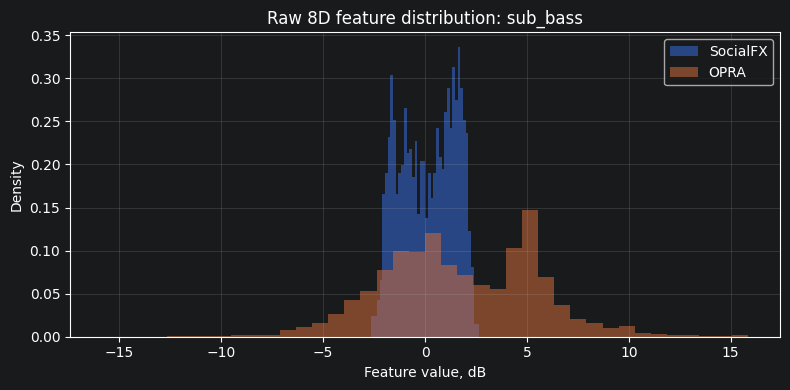

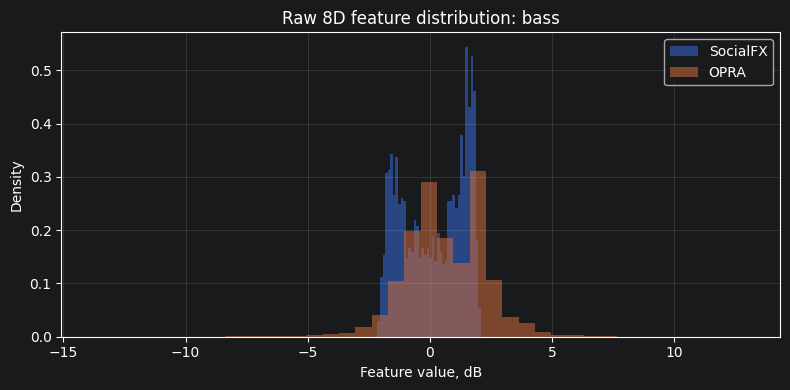

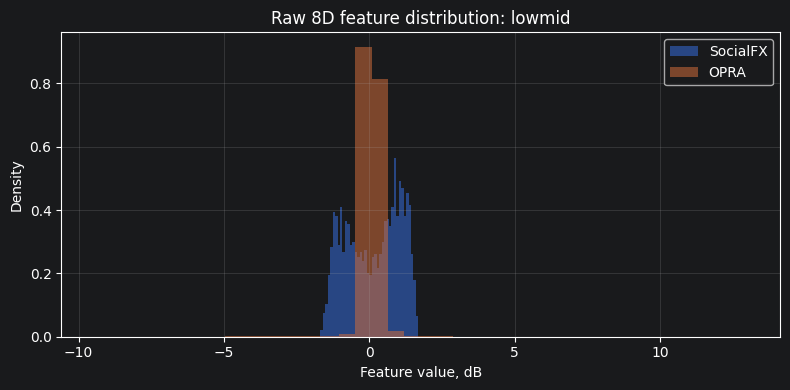

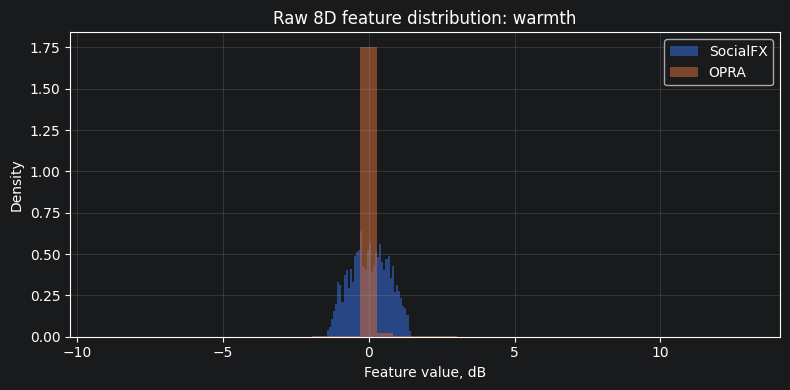

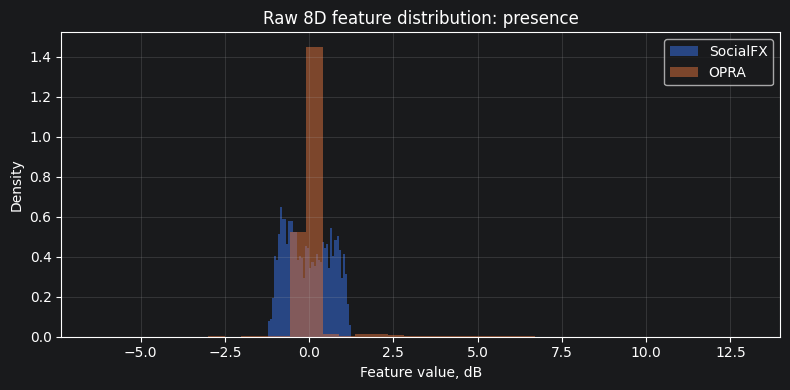

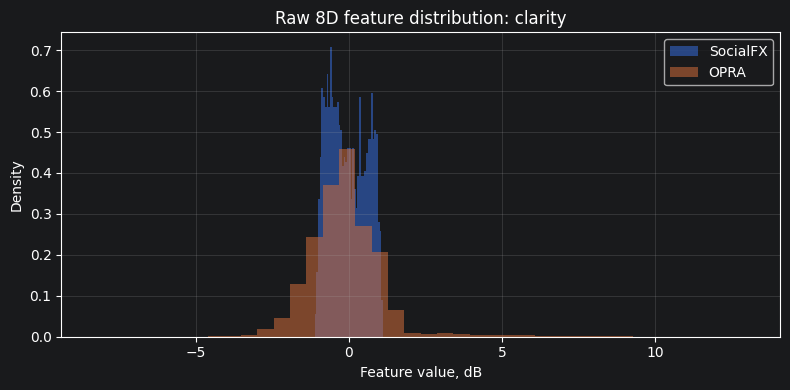

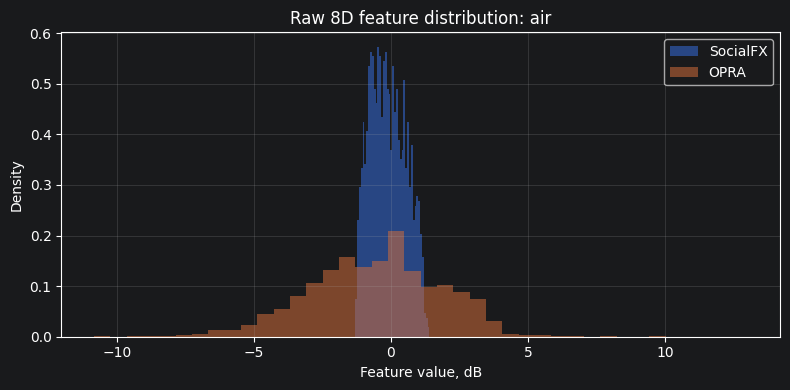

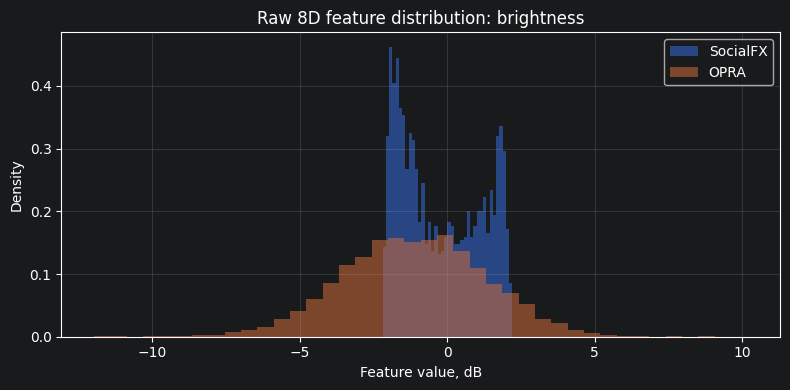

In [8]:
# ==== Compare raw feature distributions ====

for feature_name in FEATURE_NAMES_8D:
    col = f"z8_{feature_name}"

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.hist(
        df_socialfx_8d[col],
        bins=40,
        alpha=0.55,
        density=True,
        label="SocialFX",
    )

    ax.hist(
        df_opra_8d[col],
        bins=40,
        alpha=0.55,
        density=True,
        label="OPRA",
    )

    ax.set_title(f"Raw 8D feature distribution: {feature_name}")
    ax.set_xlabel("Feature value, dB")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [9]:
# ==== Summary table: SocialFX vs OPRA ====

summary_rows = []

for dataset_name, df in [
    ("socialfx", df_socialfx_8d),
    ("opra", df_opra_8d),
]:
    for feature_name in FEATURE_NAMES_8D:
        col = f"z8_{feature_name}"

        summary_rows.append({
            "dataset": dataset_name,
            "feature": feature_name,
            "count": len(df),
            "mean": df[col].mean(),
            "std": df[col].std(),
            "min": df[col].min(),
            "p05": df[col].quantile(0.05),
            "p25": df[col].quantile(0.25),
            "median": df[col].median(),
            "p75": df[col].quantile(0.75),
            "p95": df[col].quantile(0.95),
            "max": df[col].max(),
        })

df_feature_summary = pd.DataFrame(summary_rows)
display(df_feature_summary)


,dataset,feature,count,mean,std,min,p05,p25,median,p75,p95,max
0,socialfx,sub_bass,1595,0.145988,1.331775,-2.627099,-1.923497,-1.031449,0.237382,1.351548,2.041243,2.662395
1,socialfx,bass,1595,0.170755,1.271992,-2.147754,-1.761091,-1.094162,0.338289,1.394924,1.822519,2.091815
2,socialfx,lowmid,1595,0.139351,0.915243,-1.684730,-1.280471,-0.714281,0.252611,0.962161,1.415763,1.685256
3,socialfx,warmth,1595,0.028420,0.659598,-1.438897,-1.054823,-0.471092,0.028399,0.558256,1.089501,1.435845
4,socialfx,presence,1595,-0.022483,0.655444,-1.231751,-0.968599,-0.599072,-0.064378,0.556198,1.024538,1.248413
5,socialfx,clarity,1595,-0.039361,0.603344,-1.118185,-0.904179,-0.575122,-0.094912,0.503973,0.914516,1.113194
6,socialfx,air,1595,-0.103678,0.641254,-1.306204,-1.068480,-0.632618,-0.154883,0.410104,0.996662,1.406848
7,socialfx,brightness,1595,-0.216918,1.354837,-2.188290,-1.969568,-1.497257,-0.445249,1.071731,1.912630,2.203886
8,opra,sub_bass,12593,1.720426,3.799059,-15.834447,-4.169947,-0.983365,1.419276,4.820220,7.482751,15.834446
9,opra,bass,12593,0.677034,1.642415,-13.751803,-1.757151,-0.396019,0.528097,1.958310,3.079388,12.999125


## 6. 2D PCA projection

Простая визуальная проверка overlap между SocialFX и OPRA/OPRA в новом 8D-пространстве.

Используем SVD без sklearn, чтобы не зависеть от лишних библиотек.


Explained variance: [0.58563225 0.33871057]


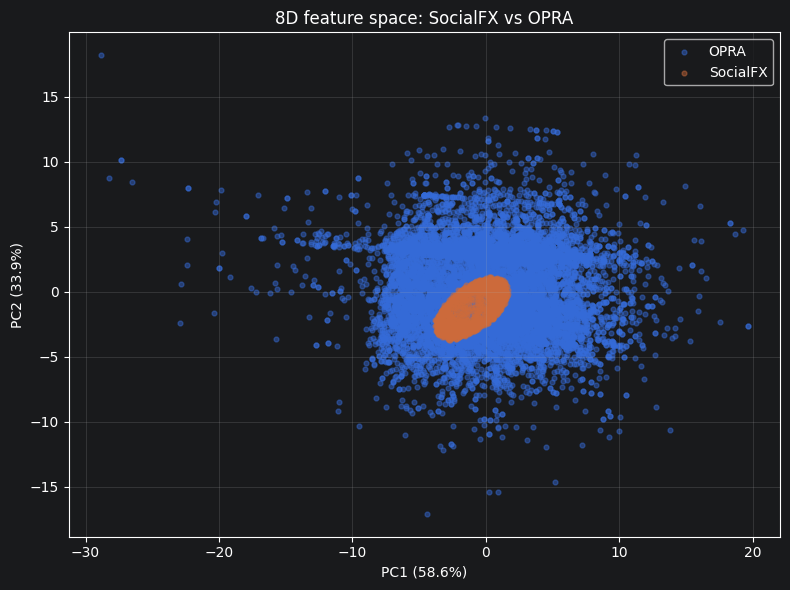

In [10]:
# ==== PCA via SVD ====

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    X_centered = X - X.mean(axis=0, keepdims=True)

    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    coords = X_centered @ Vt[:2].T

    explained = (S ** 2) / np.sum(S ** 2)
    return coords, explained[:2]


df_socialfx_pca = df_socialfx_8d[norm_cols].copy()
df_socialfx_pca["dataset"] = "SocialFX"

df_opra_pca = df_opra_8d[norm_cols].copy()
df_opra_pca["dataset"] = "OPRA"

df_pca_all = pd.concat([df_socialfx_pca, df_opra_pca], ignore_index=True)

X = df_pca_all[norm_cols].values
coords, explained = pca_2d(X)

df_pca_all["pc1"] = coords[:, 0]
df_pca_all["pc2"] = coords[:, 1]

print("Explained variance:", explained)

fig, ax = plt.subplots(figsize=(8, 6))

for dataset_name, sub in df_pca_all.groupby("dataset"):
    ax.scatter(
        sub["pc1"],
        sub["pc2"],
        s=12,
        alpha=0.45,
        label=dataset_name,
    )

ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}%)")
ax.set_title("8D feature space: SocialFX vs OPRA")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 7. Mean curves by dataset

Контрольная проверка, что внешние профили реально отличаются от SocialFX.


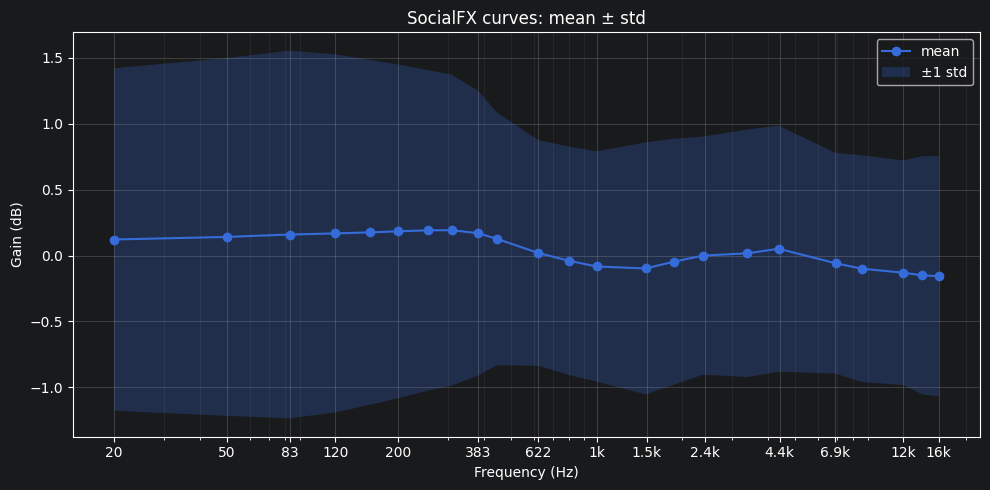

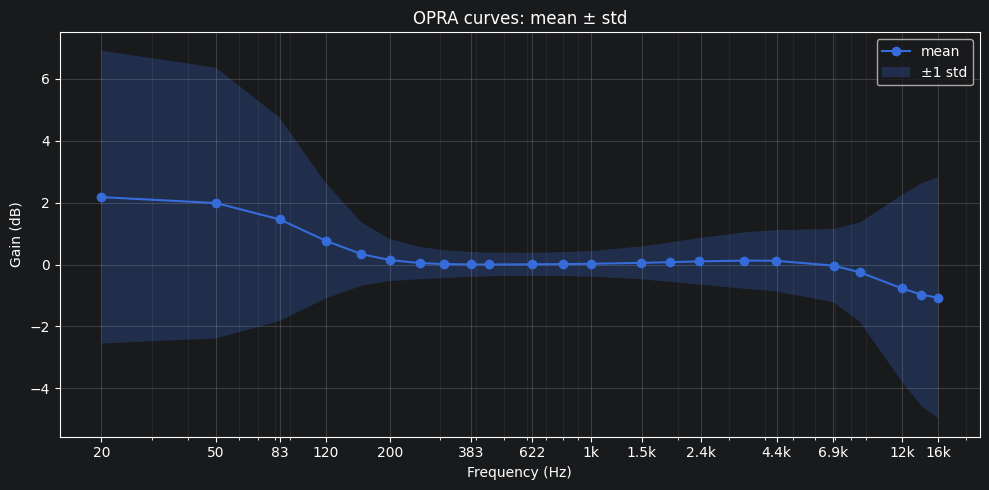

In [11]:
# ==== Mean ± std curves by dataset ====

def plot_mean_std_curves(df, title):
    curves = np.stack(df["curve_23"].values)

    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        freqs_23,
        mean_curve,
        marker="o",
        label="mean",
    )

    ax.fill_between(
        freqs_23,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.25,
        label="±1 std",
    )

    style_freq_axis(
        ax,
        freqs_23,
        ylabel="Gain (dB)",
        title=title,
        legend=True,
        legend_ncol=1,
    )

    plt.show()


plot_mean_std_curves(
    df_socialfx_8d,
    "SocialFX curves: mean ± std",
)

plot_mean_std_curves(
    df_opra_8d,
    "OPRA curves: mean ± std",
)


## 8. Сохранение файлов

Сохраняем:

```text
outputs/socialfx_curves_with_8d.parquet
outputs/opra_eq_profiles_with_8d.parquet
outputs/feature_space_v2_8d_stats.csv
outputs/socialfx_opra_8d_features.parquet
```

Для совместимости массивы `z8_raw`, `z8_norm`, `curve_23`, `freqs_23` сохраняются как JSON-строки.


In [12]:
# ==== Save helpers ====

def array_to_json(arr):
    return json.dumps([float(x) for x in np.asarray(arr).ravel()])


def prepare_df_for_parquet(df):
    df = df.copy()

    for col in ["curve_23", "freqs_23", "z8_raw", "z8_norm"]:
        if col in df.columns:
            df[f"{col}_json"] = df[col].apply(array_to_json)
            df = df.drop(columns=[col])

    return df


df_socialfx_save = prepare_df_for_parquet(df_socialfx_8d)
df_opra_save = prepare_df_for_parquet(df_opra_8d)

df_socialfx_save.to_parquet(SOCIALFX_OUT, index=False)
df_opra_save.to_parquet(OPRA_OUT, index=False)
df_stats.to_csv(FEATURE_STATS_OUT, index=False)

# Combined lightweight feature table for quick analysis.
socialfx_features = df_socialfx_8d[["source_dataset"] + raw_cols + norm_cols].copy()
opra_features = df_opra_8d[["source_dataset"] + raw_cols + norm_cols].copy()

df_combined_features = pd.concat(
    [socialfx_features, opra_features],
    ignore_index=True,
)

df_combined_features.to_parquet(COMBINED_FEATURES_OUT, index=False)

print("Saved:")
print(" ", SOCIALFX_OUT.resolve())
print(" ", OPRA_OUT.resolve())
print(" ", FEATURE_STATS_OUT.resolve())
print(" ", COMBINED_FEATURES_OUT.resolve())


Saved:
  C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\socialfx_curves_with_8d.parquet
  C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\opra_eq_profiles_with_8d.parquet
  C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\feature_space_v2_8d_stats.csv
  C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\socialfx_opra_8d_features.parquet


## 9. Проверка загрузки сохранённых файлов

Эта ячейка нужна, чтобы убедиться, что следующий ноутбук сможет нормально открыть результат.


In [13]:
# ==== Reload check ====

def load_8d_dataset(path):
    df = pd.read_parquet(path).copy()

    for base_col in ["curve_23", "freqs_23", "z8_raw", "z8_norm"]:
        json_col = f"{base_col}_json"
        if json_col in df.columns:
            df[base_col] = df[json_col].apply(
                lambda s: np.asarray(json.loads(s), dtype=np.float32)
            )

    return df


df_socialfx_check = load_8d_dataset(SOCIALFX_OUT)
df_opra_check = load_8d_dataset(OPRA_OUT)

print("SocialFX loaded:", df_socialfx_check.shape)
print("OPRA loaded:", df_opra_check.shape)

display(df_socialfx_check.head())
display(df_opra_check.head())


SocialFX loaded: (1595, 57)
OPRA loaded: (12593, 57)


,id,text,lang,ratings_consistency,curve_40,freqs_40,n_bands_40,n_bands_23,bass_40_raw,bass_23_raw,...,z8n_air,z8n_brightness,curve_23_json,freqs_23_json,z8_raw_json,z8_norm_json,curve_23,freqs_23,z8_raw,z8_norm
0,eq_0,hot,English,0.797209,"[-1.2872984409332275, -1.5329641103744507, -1....","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...",40,23,-1.287566,-1.290872,...,-0.706571,0.293874,"[-1.2872984409332275, -1.5329641103744507, -1....","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2...","[-1.465518593788147, -1.1774649620056152, 0.27...","[-1.2100446224212646, -1.0599281787872314, 0.1...","[-1.2872984, -1.5329641, -1.5065393, -1.396974...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...","[-1.4655186, -1.177465, 0.27107856, 1.1588559,...","[-1.2100446, -1.0599282, 0.14392601, 1.7138251..."
1,eq_1,wet,English,0.481343,"[-0.9765962958335876, -0.7818208336830139, -0....","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...",40,23,-0.725170,-0.726108,...,2.355583,1.531152,"[-0.9765962958335876, -0.7818208336830139, -0....","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2...","[-0.7437889575958252, -0.7635607123374939, -0....","[-0.6681138873100281, -0.7345297336578369, -1....","[-0.9765963, -0.78182083, -0.56064045, -0.6097...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...","[-0.74378896, -0.7635607, -0.8674335, -0.74650...","[-0.6681139, -0.73452973, -1.1000185, -1.17484..."
2,eq_10,warm,English,0.806225,"[1.970152497291565, 2.0636439323425293, 2.1096...","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...",40,23,1.904597,1.906948,...,-0.814871,-1.210883,"[1.970152497291565, 2.0636439323425293, 2.1096...","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2...","[2.045807123184204, 1.8160587549209595, 0.7950...","[1.4265319108963013, 1.293485403060913, 0.7164...","[1.9701525, 2.063644, 2.1096215, 2.019063, 1.8...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...","[2.0458071, 1.8160588, 0.79504406, -0.24542004...","[1.4265319, 1.2934854, 0.71641356, -0.4151615,..."
3,eq_100,calm,English,0.754685,"[1.3558952808380127, 1.202727198600769, 1.1038...","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...",40,23,0.913167,0.914097,...,0.811071,0.093839,"[1.3558952808380127, 1.202727198600769, 1.1038...","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2...","[1.1658457517623901, 0.8007308840751648, -0.17...","[0.7657884955406189, 0.49526679515838623, -0.3...","[1.3558953, 1.2027272, 1.1038468, 0.9991057, 0...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...","[1.1658458, 0.8007309, -0.1718302, -1.0198618,...","[0.7657885, 0.4952668, -0.33999854, -1.5892725..."
4,eq_1000,angelical,Español,0.428656,"[0.09275069832801819, 0.3474467396736145, 0.57...","[20.0, 50.0, 83.0, 120.0, 161.0, 208.0, 259.0,...",40,23,0.873460,0.881261,...,1.042834,-0.108023,"[0.09275069832801819, 0.3474467396736145, 0.57...","[20.0, 50.0, 83.0, 120.0, 159.5102996826172, 2...","[0.4464247226715088, 1.0518150329589844, 0.885...","[0.22559115290641785, 0.6926612257957458, 0.81...","[0.0927507, 0.34744674, 0.57004803, 0.8858108,...","[20.0, 50.0, 83.0, 120.0, 159.5103, 200.04376,...","[0.44642472, 1.051815, 0.8851775, -0.37976235,...","[0.22559115, 0.6926612, 0.81489384, -0.6188344..."


,source_dataset,relative_path,filename,suffix,profile_type,num_points,num_filters,gain_min,gain_max,gain_abs_max,...,z8n_warmth,z8n_presence,z8n_clarity,z8n_air,z8n_brightness,z8_raw_json,z8_norm_json,curve_23,z8_raw,z8_norm
0,opra,database\vendors\1custom\products\sa02\eq\auto...,info.json,.json,json_parametric,0,10,-1.055203,5.488164,5.488164,...,0.002331,-0.001788,-0.326772,-0.809600,-1.565261,"[4.495275974273682, 1.824123740196228, 0.20799...","[3.2657837867736816, 1.29982590675354, 0.07500...","[5.4881635, 5.1938915, 3.9035857, 2.0669541, 0...","[4.495276, 1.8241237, 0.20799944, 0.029957378,...","[3.2657838, 1.2998259, 0.07500542, 0.002331110..."
1,opra,database\vendors\1custom\products\sa03\eq\auto...,info.json,.json,json_parametric,0,10,-1.822291,2.395032,2.395032,...,-0.024500,-0.029413,-0.612454,-1.517421,-1.053189,"[1.965944528579712, 0.7925931215286255, 0.0882...","[1.3665648698806763, 0.4888691306114197, -0.05...","[2.3950322, 2.271908, 1.7140299, 0.8947236, 0....","[1.9659445, 0.7925931, 0.08823836, 0.012259618...","[1.3665649, 0.48886913, -0.055846192, -0.02450..."
2,opra,database\vendors\1custom\products\sa05\eq\auto...,info.json,.json,json_parametric,0,10,-2.397266,2.893972,2.893972,...,-0.020600,-0.049771,-0.827075,-2.047376,-1.372327,"[2.3749420642852783, 0.958160936832428, 0.1069...","[1.6736719608306885, 0.6190333366394043, -0.03...","[2.8939717, 2.7445095, 2.0696988, 1.0820913, 0...","[2.374942, 0.95816094, 0.1069374, 0.014832235,...","[1.673672, 0.61903334, -0.035415515, -0.020599..."
3,opra,database\vendors\1more\products\1m301_single_d...,info.json,.json,json_parametric,0,7,0.000483,9.989346,9.989346,...,0.046066,0.100069,0.607735,1.224001,-2.026546,"[8.330513954162598, 3.5946717262268066, 0.4363...","[6.145578861236572, 2.691774606704712, 0.32453...","[9.9893465, 9.523152, 7.374416, 4.215076, 2.02...","[8.330514, 3.5946717, 0.436376, 0.05880479, 0....","[6.145579, 2.6917746, 0.3245309, 0.046065927, ..."
4,opra,database\vendors\1more\products\aero\eq\autoeq...,info.json,.json,json_parametric,0,10,0.000390,3.641548,3.641548,...,-0.041015,0.163774,1.424505,3.518852,1.369275,"[0.0819605216383934, 0.03300860524177551, 0.00...","[-0.04807692766189575, -0.10829216986894608, -...","[0.09979513, 0.09471751, 0.07152903, 0.0372154...","[0.08196052, 0.033008605, 0.003787281, 0.00136...","[-0.048076928, -0.10829217, -0.1481179, -0.041..."


## 10. Промежуточный вывод

После запуска этого ноутбука нужно посмотреть:

1. Расширяет ли OPRA/OPRA диапазон `sub_bass`, `bass`, `air`, `brightness`.
2. Насколько OPRA/OPRA пересекается с SocialFX в PCA.
3. Не слишком ли OPRA отличается как headphone compensation dataset.

Дальше возможны варианты:

```text
A. 8D только на SocialFX
B. 8D SocialFX + OPRA как pretraining
C. 8D SocialFX + OPRA как weighted augmentation
D. OPRA только как out-of-domain test
```
